### 🔁 What is Iterative Retrieval in Agentic RAG?
Combined both Iterative And Self reflection

✅ Definition:
Iterative Retrieval is a dynamic strategy where an AI agent doesn't settle for the first batch of retrieved documents. Instead, it evaluates the adequacy of the initial context, and if necessary, it:

- Refines the query,
- Retrieves again,
- Repeats the process until it’s confident enough to answer the original question.

🧠 Why Use It?
In standard RAG:

- A single retrieval step is done, and the LLM uses it to answer.
- If the documents were incomplete or irrelevant, the answer may fail.

In Iterative RAG:

- The agent reflects on the retrieved content and the answer it produced.
- If it’s unsure, it can refine its search (like a human researcher would).

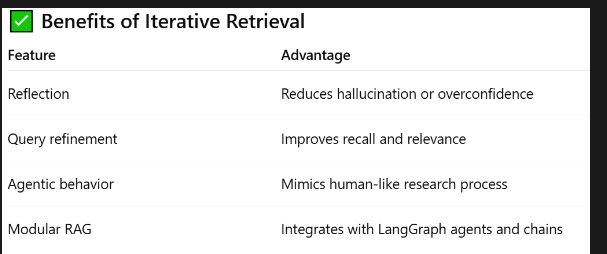

In [28]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langchain_classic.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [29]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
llm=init_chat_model("ollama:llama3.2:latest")

In [30]:
### Load And Embed Documents
from langchain_ollama import OllamaEmbeddings
docs = TextLoader("sample_docs.txt", encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vectorstore = FAISS.from_documents(chunks, OllamaEmbeddings(model="llama3.2:latest"))
retriever = vectorstore.as_retriever()

In [31]:
### Define Agent State

class IterativeRAGState(BaseModel):
    question: str
    refined_question: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    verified: bool = False
    attempts: int = 0


In [32]:
### Retrieve Node
def retrieve_docs(state: IterativeRAGState) -> IterativeRAGState:
    query = state.refined_question or state.question
    docs = retriever.invoke(query)
    return state.model_copy(update={"retrieved_docs": docs})


In [33]:
### Reflect And Verify
def generate_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    response = llm.invoke(prompt.strip()).content.strip()
    return state.model_copy(update={"answer": response, "attempts": state.attempts + 1})

In [34]:
## Reflect on answer
def reflect_on_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
Evaluate whether the answer below is factually sufficient and complete.

Question: {state.question}
Answer: {state.answer}

Respond 'YES' if it's complete, otherwise 'NO' with feedback.
"""
    feedback = llm.invoke(prompt).content.lower()
    verified = "yes" in feedback
    return state.model_copy(update={"verified": verified})


In [35]:
## Refine query
def refine_query(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
The answer appears incomplete. Suggest a better version of the query that would help retrieve more relevant context.

Original Question: {state.question}
Current Answer: {state.answer}
"""
    new_query = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"refined_question": new_query})


In [36]:
builder = StateGraph(IterativeRAGState)

builder.add_node("retrieve", retrieve_docs)
builder.add_node("answer", generate_answer)
builder.add_node("reflect", reflect_on_answer)
builder.add_node("refine", refine_query)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "answer")
builder.add_edge("answer", "reflect")

# builder.add_conditional_edges(
#     "reflect",
#     lambda s: END if s.verified or s.attempts >= 2 else "refine"
# )
builder.add_conditional_edges(
    "reflect",
    lambda s: "end" if s.verified or s.attempts >= 2 else "refine",
    {
        "refine": "refine",
        "end": END
    }
)
builder.add_edge("refine", "retrieve")
builder.add_edge("answer", END)

graph = builder.compile()


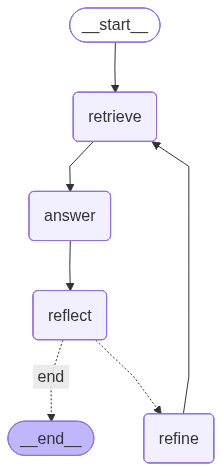

In [37]:
graph

In [38]:
query = "agent loops  and transformer-based systems?"

initial_state = IterativeRAGState(question=query)
final = graph.invoke(initial_state)

print("✅ Final Answer:\n", final["answer"])
print("\n🧠 Verified:", final["verified"])
print("🔁 Attempts:", final["attempts"])


✅ Final Answer:
 Based on the context provided, it appears that agent loops are a key component of AI systems that rely on continuous learning and adaptation. Transformer-based systems, which have gained significant attention in recent years due to their effectiveness in natural language processing tasks, can benefit from agent loop architectures.

Transformer-based systems typically operate in an online learning setting, where they receive input data at each time step and produce output. In this context, the agent loop can be seen as a continuous cycle of thinking, acting, and observing, where the model processes new input data, generates predictions or actions, and receives feedback from the environment.

The transformer architecture's ability to process sequential data and generate outputs makes it well-suited for applications that require real-time adaptation and learning. By incorporating agent loop architectures into transformer-based systems, researchers can leverage the strengt

In [40]:
final

{'question': 'agent loops  and transformer-based systems?',
 'refined_question': '',
 'retrieved_docs': [Document(id='42d824f4-f12d-47ab-8f60-e5d2a9409ec4', metadata={'source': 'sample_docs.txt'}, page_content='An agent loop is the cycle of thinking, acting, and observing. It allows an AI agent to continuously refine its actions based on results.\nThis feedback loop is crucial in autonomous systems to adapt in real-time.\nAgent-based architectures benefit from memory, planning, and interaction with tools.')],
 'answer': "Based on the context provided, it appears that agent loops are a key component of AI systems that rely on continuous learning and adaptation. Transformer-based systems, which have gained significant attention in recent years due to their effectiveness in natural language processing tasks, can benefit from agent loop architectures.\n\nTransformer-based systems typically operate in an online learning setting, where they receive input data at each time step and produce ou

![image.png](attachment:image.png)